# Positive multi-output GP on a real 2D sea-ice region

This notebook extends the softplus-positive multi-output GP from a one-dimensional
transect to two spatial coordinates $(x,y)$.

The region was selected without using model error: among all possible 20×20
cells on the 25 km EASE grid, the extraction selected the 500 km square with
the greatest number of valid March 8 CS2–IS2 window-averaged pairs. The selected
475×475 km centre-to-centre extent contains 296 of 400 possible cells (74%).

Validation uses four contiguous spatial quadrants. Each point is predicted by
a model that did not observe its quadrant. Noise (0.05/0.02 m), length scales
(200/100 km), and 49 inducing locations were fixed before evaluating the held-out
quadrants.


In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

obs=np.genfromtxt('../data/processed/real_data_March8_dense_2D_region.csv',delimiter=',',names=True,dtype=None,encoding='utf-8')
cv=np.genfromtxt('../results/positive_gp_2d_blocked_predictions.csv',delimiter=',',names=True,dtype=None,encoding='utf-8')
grid=np.genfromtxt('../results/positive_gp_2d_full_grid.csv',delimiter=',',names=True,dtype=None,encoding='utf-8')
summary=json.load(open('../results/positive_gp_2d_summary.json'))
print(summary['region'])
print('fold sizes:', {int(f):int((cv['fold']==f).sum()) for f in np.unique(cv['fold'])})


{'rows': 296, 'extent_km': [475.0, 475.0], 'occupied_fraction_of_20x20_grid': 0.74, 'quadrant_fold_sizes': [78, 81, 79, 58]}
fold sizes: {0: 78, 1: 81, 2: 79, 3: 58}


## Observations and spatial folds


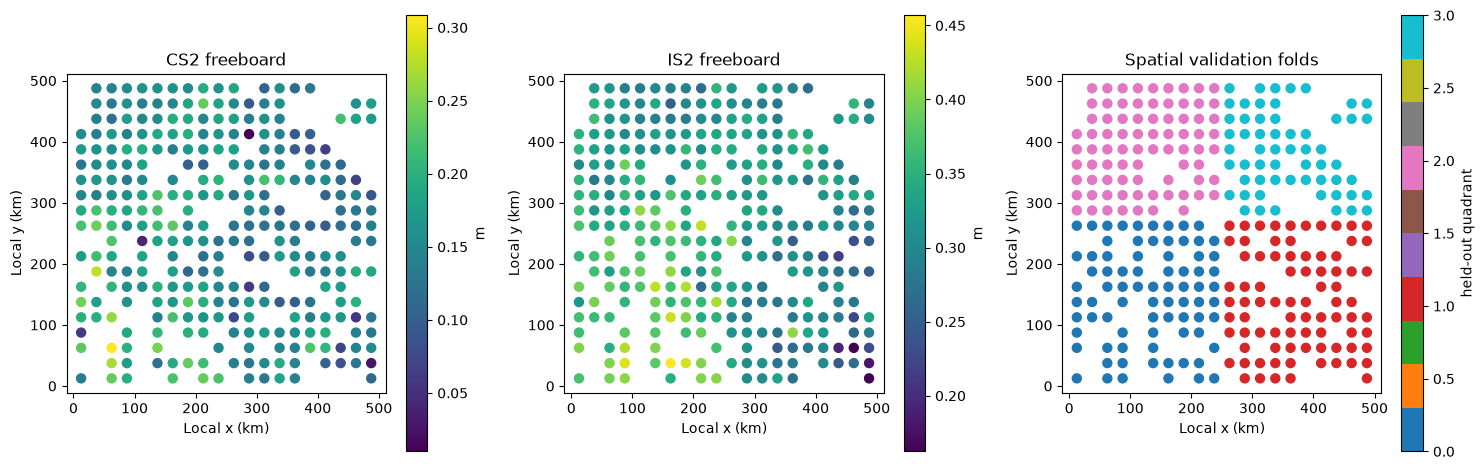

In [2]:
fig,axs=plt.subplots(1,3,figsize=(15,4.8))
for ax,name,title in [
    (axs[0],'freeboard_cs2_m','CS2 freeboard'),
    (axs[1],'freeboard_is2_m','IS2 freeboard')]:
    sc=ax.scatter(obs['local_x_km'],obs['local_y_km'],c=obs[name],s=42,cmap='viridis')
    plt.colorbar(sc,ax=ax,label='m');ax.set_title(title)
sc=axs[2].scatter(cv['local_x_km'],cv['local_y_km'],c=cv['fold'],s=42,cmap='tab10')
plt.colorbar(sc,ax=axs[2],label='held-out quadrant');axs[2].set_title('Spatial validation folds')
for ax in axs: ax.set_xlabel('Local x (km)');ax.set_ylabel('Local y (km)');ax.set_aspect('equal')
plt.tight_layout()


## Held-out freeboard performance


In [3]:
for method,key in [('Point inversion + nearest','point_nearest'),('Positive GP','positive_gp')]:
    print(method)
    for sensor in ['CS2','IS2']:
        m=summary[key][sensor]
        print(f"  {sensor}: RMSE={m['RMSE_m']:.4f} m, MAE={m['MAE_m']:.4f} m, bias={m['bias_m']:.4f} m")

for sensor in ['cs2','is2']:
    baseline=summary['point_nearest'][sensor.upper()]['RMSE_m']
    model=summary['positive_gp'][sensor.upper()]['RMSE_m']
    print(sensor.upper(),'relative RMSE reduction:',f'{100*(baseline-model)/baseline:.1f}%')


Point inversion + nearest
  CS2: RMSE=0.0539 m, MAE=0.0425 m, bias=0.0040 m
  IS2: RMSE=0.0540 m, MAE=0.0407 m, bias=0.0106 m
Positive GP
  CS2: RMSE=0.0471 m, MAE=0.0357 m, bias=-0.0195 m
  IS2: RMSE=0.0452 m, MAE=0.0350 m, bias=0.0215 m
CS2 relative RMSE reduction: 12.6%
IS2 relative RMSE reduction: 16.2%


In [4]:
def rmse(a,b): return float(np.sqrt(np.mean((a-b)**2)))
for fold in np.unique(cv['fold']):
    d=cv[cv['fold']==fold]
    print('fold',int(fold),'n=',len(d))
    for method,prefix in [('nearest','point'),('positive GP','positive_gp')]:
        print(' ',method,
              'CS2',f"{rmse(d['actual_cs2_m'],d[f'{prefix}_pred_cs2_m']):.4f}",
              'IS2',f"{rmse(d['actual_is2_m'],d[f'{prefix}_pred_is2_m']):.4f}")


fold 0 n= 78
  nearest CS2 0.0623 IS2 0.0535
  positive GP CS2 0.0640 IS2 0.0363
fold 1 n= 81
  nearest CS2 0.0534 IS2 0.0762
  positive GP CS2 0.0471 IS2 0.0598
fold 2 n= 79
  nearest CS2 0.0499 IS2 0.0352
  positive GP CS2 0.0303 IS2 0.0404
fold 3 n= 58
  nearest CS2 0.0476 IS2 0.0348
  positive GP CS2 0.0385 IS2 0.0381


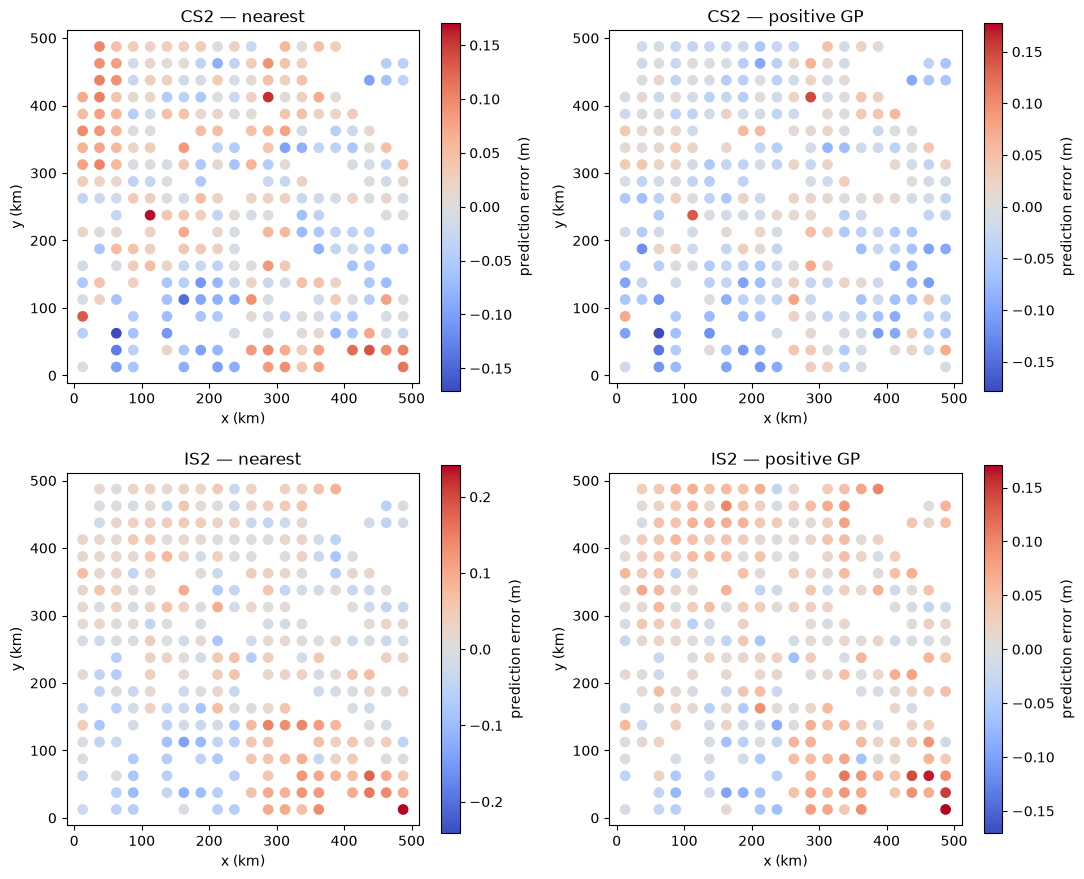

In [5]:
fig,axs=plt.subplots(2,2,figsize=(11,9))
for row,sensor in enumerate(['cs2','is2']):
    for col,(method,prefix) in enumerate([('nearest','point'),('positive GP','positive_gp')]):
        error=cv[f'{prefix}_pred_{sensor}_m']-cv[f'actual_{sensor}_m']
        limit=np.max(np.abs(error))
        sc=axs[row,col].scatter(cv['local_x_km'],cv['local_y_km'],c=error,s=45,cmap='coolwarm',vmin=-limit,vmax=limit)
        plt.colorbar(sc,ax=axs[row,col],label='prediction error (m)')
        axs[row,col].set_title(f'{sensor.upper()} — {method}')
        axs[row,col].set_aspect('equal');axs[row,col].set_xlabel('x (km)');axs[row,col].set_ylabel('y (km)')
plt.tight_layout()


## Out-of-fold latent fields


negative positive-GP Hi: 0
negative positive-GP Hs: 0


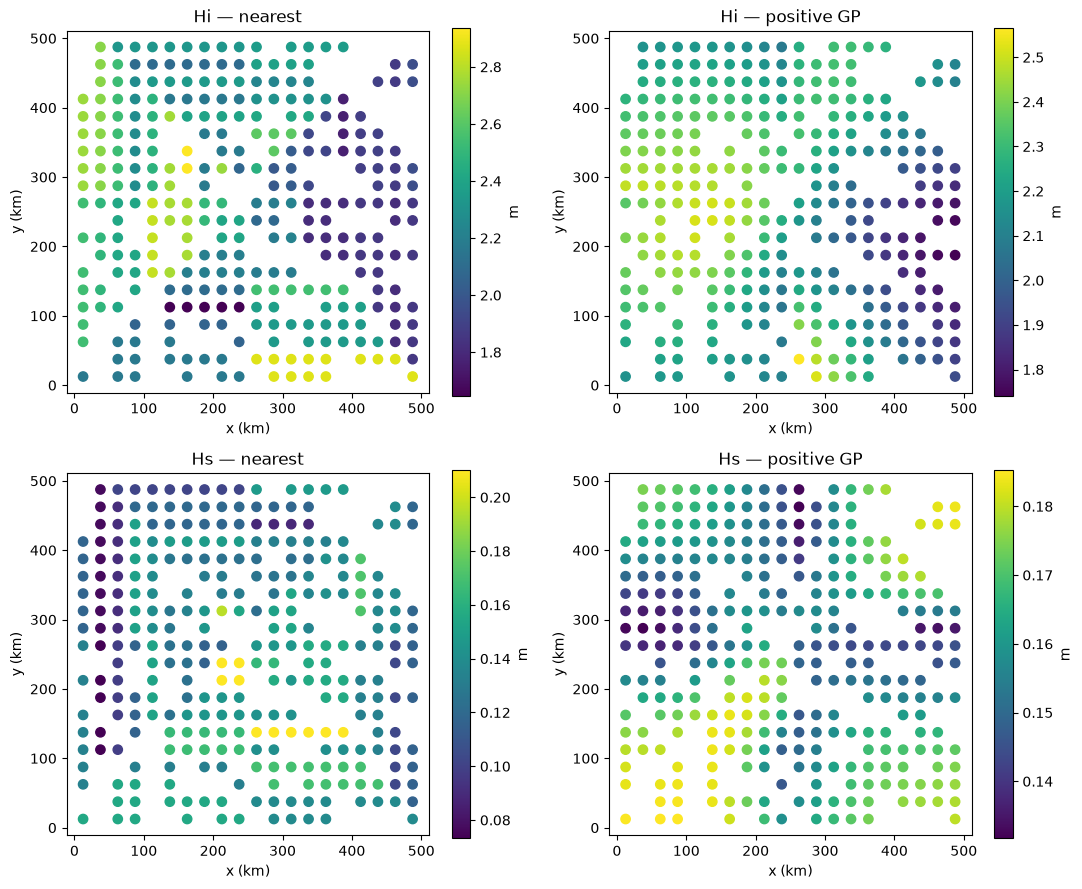

In [6]:
fig,axs=plt.subplots(2,2,figsize=(11,9))
for row,latent in enumerate(['Hi','Hs']):
    for col,(method,prefix) in enumerate([('nearest','point'),('positive GP','positive_gp')]):
        sc=axs[row,col].scatter(cv['local_x_km'],cv['local_y_km'],c=cv[f'{prefix}_{latent}_m'],s=45,cmap='viridis')
        plt.colorbar(sc,ax=axs[row,col],label='m')
        axs[row,col].set_title(f'{latent} — {method}')
        axs[row,col].set_aspect('equal');axs[row,col].set_xlabel('x (km)');axs[row,col].set_ylabel('y (km)')
plt.tight_layout()
print('negative positive-GP Hi:',int((cv['positive_gp_Hi_m']<0).sum()))
print('negative positive-GP Hs:',int((cv['positive_gp_Hs_m']<0).sum()))


## Full-data visualization maps (not validation predictions)


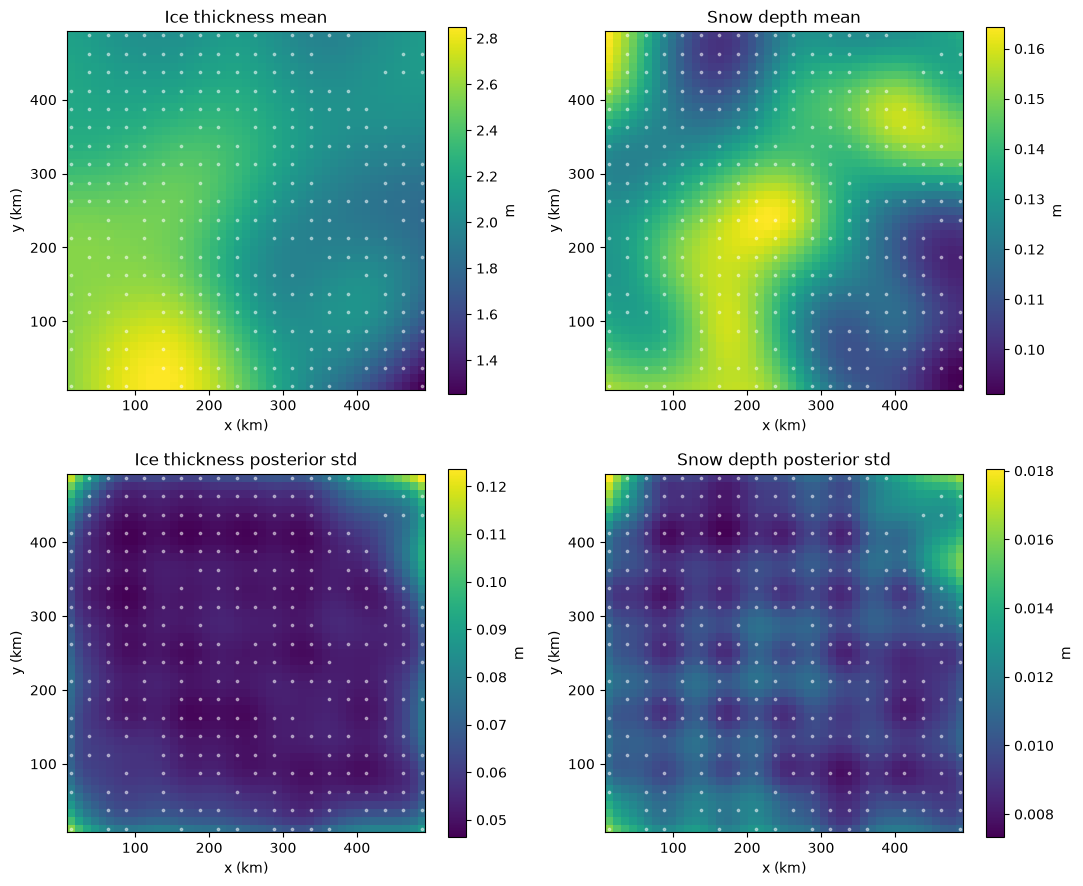

In [7]:
shape=(45,45)
xx=grid['local_x_km'].reshape(shape);yy=grid['local_y_km'].reshape(shape)
fig,axs=plt.subplots(2,2,figsize=(11,9))
for ax,name,title in [
    (axs[0,0],'positive_gp_Hi_m','Ice thickness mean'),
    (axs[0,1],'positive_gp_Hs_m','Snow depth mean'),
    (axs[1,0],'positive_gp_Hi_std_m','Ice thickness posterior std'),
    (axs[1,1],'positive_gp_Hs_std_m','Snow depth posterior std')]:
    values=grid[name].reshape(shape)
    im=ax.pcolormesh(xx,yy,values,shading='auto',cmap='viridis')
    ax.scatter(obs['local_x_km'],obs['local_y_km'],s=3,color='white',alpha=.45)
    plt.colorbar(im,ax=ax,label='m');ax.set_title(title);ax.set_aspect('equal')
    ax.set_xlabel('x (km)');ax.set_ylabel('y (km)')
plt.tight_layout()


## Evidence-based interpretation

- The two-dimensional positive GP reduces held-out RMSE by 12.6% for CS2 and
  16.2% for IS2 relative to pointwise inversion plus nearest-neighbour transfer.
- All four spatial quadrants are predicted out of sample, and no negative ice
  thickness or snow depth estimates occur.
- This 2D result is stronger than the 1D comparison in one limited sense: the
  positive GP beats its simple spatial baseline for both freeboards. It does not
  prove latent accuracy because independent $H_i/H_s$ truth is still absent.
- The fixed 1D-derived hyperparameters were transferred without retuning to the
  2D region. This avoids selecting them on the same held-out quadrant results,
  but a future large-scale model should select anisotropic length scales using
  training-only validation.
- The coloured full-grid maps use a model fitted to all 296 observations and
  are included for visualization only. Formal accuracy claims must use the
  out-of-fold values.
- Opposite freeboard biases (−0.019 m for CS2 and +0.021 m for IS2) indicate
  that the fixed sensor noise and penetration assumptions still leave systematic
  structure unexplained.

This experiment establishes that the positive multi-output likelihood extends
computationally and statistically to a small real 2D region. The next scaling
step would use multiple regions or the full Arctic with minibatched SVGP/DRF,
while preserving spatial block validation and explicit physical constraints.
